# Forecasting de Ventas - Licores Iowa

**Fase 1.1, 1.2 y 1.3**: Ejercicios SQL — consolidación, CTEs, subconsultas, EXPLAIN y optimización.


## Configuración inicial

Importo DuckDB y defino rutas. Uso `SAMPLE_ROWS` para limitar la carga en pruebas rápidas.

In [2]:
%matplotlib inline

try:
    import duckdb
except ModuleNotFoundError:
    import sys
    !{sys.executable} -m pip install duckdb
    import duckdb

import pandas as pd
from pathlib import Path

DATA_PATH = "Iowa_Liquor_Sales.csv"
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(exist_ok=True)

SAMPLE_ROWS = 500_000  # None para carga completa

---
## E1.1: Carga del CSV y CREATE TABLE raw_ventas

**Objetivo**: Practicar CTEs (Common Table Expressions). En lugar de usar una query directa, definimos primero una CTE `csv_cargado` que lee el CSV, limpia `Sale (Dollars)` y filtra filas inválidas. Luego guardamos el resultado en la tabla `raw_ventas`.

**Ventaja de usar CTE**: Separa la lógica de lectura/limpieza de la materialización, lo que facilita poder reusar la lógica.

In [3]:
con = duckdb.connect(database=":memory:")

# CTE: carga y limpieza del CSV en una expresión con nombre
# Luego CREATE TABLE materializa el resultado de la CTE
limit_clause = f" LIMIT {SAMPLE_ROWS}" if SAMPLE_ROWS else ""

con.execute(f"""
    CREATE OR REPLACE TABLE raw_ventas AS
    WITH csv_cargado AS (
        SELECT 
            "Date",
            "Category Name",
            "Store Number",
            CAST(REPLACE(REPLACE("Sale (Dollars)", '$', ''), ',', '') AS DOUBLE) AS ventas
        FROM read_csv_auto('{DATA_PATH}')
        WHERE "Sale (Dollars)" IS NOT NULL AND TRIM("Sale (Dollars)") != ''
        {limit_clause}
    )
    SELECT * FROM csv_cargado
""")

print("Tabla raw_ventas creada desde CTE.")
con.execute("SELECT COUNT(*) AS n FROM raw_ventas").fetchdf()

Tabla raw_ventas creada desde CTE.


,n
0,500000


Verifico que la tabla tiene la estructura esperada: fecha, categoría, tienda y ventas.

In [4]:
con.execute("SELECT * FROM raw_ventas LIMIT 5").fetchdf()

,Date,Category Name,Store Number,ventas
0,2015-11-20,None,2191,162.84
1,2015-11-21,None,2205,325.68
2,2015-11-16,None,3549,19.20
3,2015-11-04,None,2513,160.02
4,2015-11-17,None,3942,19.20


---
## E1.2: Vista ventas_semanal con date_trunc('week', fecha)

Crear una vista que agregue ventas por **semana**. Uso `date_trunc('week', fecha) para agrupar por semana, truncando al inicio de la semana (lunes). :
- `ventas_semanal_categoria`: ventas semanales por categoría
- `ventas_semanal_tienda`: ventas semanales por tienda

**Ventaja de usar vistas**: Permiten definir una lógica de agregación/reformateo que puede reutilizarse en múltiples queries posteriores, sin duplicar código ni recalcular resultados. Si la lógica de agregación cambia solo se debe modificar la vista.  


In [5]:
# Vista: ventas semanales POR CATEGORÍA
# date_trunc('week', fecha) agrupa todas las fechas de una misma semana
con.execute("""
    CREATE OR REPLACE VIEW ventas_semanal_categoria AS
    SELECT 
        date_trunc('week', "Date"::DATE)::DATE AS semana,
        "Category Name" AS categoria,
        SUM(ventas) AS ventas
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

print("Vista ventas_semanal_categoria creada.")
df_cat = con.execute("SELECT * FROM ventas_semanal_categoria LIMIT 10").fetchdf()
df_cat

Vista ventas_semanal_categoria creada.


,semana,categoria,ventas
0,2012-01-02,100 PROOF VODKA,891.29
1,2012-01-02,AMERICAN ALCOHOL,625.56
2,2012-01-02,AMERICAN AMARETTO,648.51
3,2012-01-02,AMERICAN COCKTAILS,4693.71
4,2012-01-02,AMERICAN DRY GINS,2849.92
5,2012-01-02,AMERICAN GRAPE BRANDIES,2025.25
6,2012-01-02,AMERICAN SLOE GINS,89.47
7,2012-01-02,APPLE SCHNAPPS,548.04
8,2012-01-02,APRICOT BRANDIES,185.93
9,2012-01-02,BARBADOS RUM,40.50


In [6]:
# Vista: ventas semanales POR TIENDA
con.execute("""
    CREATE OR REPLACE VIEW ventas_semanal_tienda AS
    SELECT 
        date_trunc('week', "Date"::DATE)::DATE AS semana,
        "Store Number" AS store_id,
        SUM(ventas) AS ventas
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

print("Vista ventas_semanal_tienda creada.")
df_store = con.execute("SELECT * FROM ventas_semanal_tienda LIMIT 10").fetchdf()
df_store

Vista ventas_semanal_tienda creada.


,semana,store_id,ventas
0,2012-01-02,2106,1131.60
1,2012-01-02,2190,4579.67
2,2012-01-02,2191,234.98
3,2012-01-02,2200,124.69
4,2012-01-02,2205,89.88
5,2012-01-02,2233,543.66
6,2012-01-02,2238,131.15
7,2012-01-02,2290,1295.83
8,2012-01-02,2327,19.98
9,2012-01-02,2367,71.64


Resumen: cantidad de filas y rango de semanas en cada vista.

In [7]:
n_cat = con.execute("SELECT COUNT(*) AS n FROM ventas_semanal_categoria").fetchone()[0]
n_store = con.execute("SELECT COUNT(*) AS n FROM ventas_semanal_tienda").fetchone()[0]
rango = con.execute("SELECT MIN(semana) AS min_s, MAX(semana) AS max_s FROM ventas_semanal_categoria").fetchone()
print(f"ventas_semanal_categoria: {n_cat:,} filas")
print(f"ventas_semanal_tienda: {n_store:,} filas")
print(f"Rango semanas: {rango[0]} a {rango[1]}")

ventas_semanal_categoria: 12,545 filas
ventas_semanal_tienda: 139,152 filas
Rango semanas: 2012-01-02 a 2015-11-30


---
## E1.3: ROW_NUMBER() — Ranking de días con más ventas por categoría

**Objetivo**: Para cada categoría, ordenar los días por ventas descendentes y asignar un ranking. Así identificamos los días con más ventas por categoría.

**ROW_NUMBER() OVER (PARTITION BY categoria ORDER BY ventas DESC)**: Dentro de cada categoría (`PARTITION BY`), numera las filas según ventas de mayor a menor. El día con más ventas obtiene rank 1.

In [8]:
# Necesitamos ventas diarias por categoría como base
# Luego aplicamos ROW_NUMBER() particionado por categoría
df_ranking = con.execute("""
    WITH ventas_diarias_cat AS (
        SELECT 
            "Date"::DATE AS fecha,
            "Category Name" AS categoria,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
        GROUP BY 1, 2
    )
    SELECT 
        categoria,
        fecha,
        ventas,
        ROW_NUMBER() OVER (PARTITION BY categoria ORDER BY ventas DESC) AS rank_ventas
    FROM ventas_diarias_cat
    ORDER BY categoria, rank_ventas
""").fetchdf()

df_ranking.head(15)

,categoria,fecha,ventas,rank_ventas
0,100 PROOF VODKA,2014-06-17,3753.94,1
1,100 PROOF VODKA,2015-10-01,2755.89,2
2,100 PROOF VODKA,2015-09-14,2636.04,3
3,100 PROOF VODKA,2015-11-11,2112.48,4
4,100 PROOF VODKA,2014-06-04,2017.12,5
5,100 PROOF VODKA,2015-03-12,1412.29,6
6,100 PROOF VODKA,2013-06-13,1379.86,7
7,100 PROOF VODKA,2014-08-25,1307.61,8
8,100 PROOF VODKA,2012-01-31,1269.57,9
9,100 PROOF VODKA,2013-06-11,1247.83,10


Filtro los **Top 3 días** con más ventas por categoría para una lectura más clara.

In [9]:
# Top 3 días con más ventas por categoría
top3 = con.execute("""
    WITH ventas_diarias_cat AS (
        SELECT 
            "Date"::DATE AS fecha,
            "Category Name" AS categoria,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
        GROUP BY 1, 2
    ),
    con_ranking AS (
        SELECT 
            categoria,
            fecha,
            ventas,
            ROW_NUMBER() OVER (PARTITION BY categoria ORDER BY ventas DESC) AS rank_ventas
        FROM ventas_diarias_cat
    )
    SELECT categoria, fecha, ventas, rank_ventas
    FROM con_ranking
    WHERE rank_ventas <= 3
    ORDER BY categoria, rank_ventas
""").fetchdf()

print("Top 3 días con más ventas por categoría (muestra):")
top3.head(20)

Top 3 días con más ventas por categoría (muestra):


,categoria,fecha,ventas,rank_ventas
0,100 PROOF VODKA,2014-06-17,3753.94,1
1,100 PROOF VODKA,2015-10-01,2755.89,2
2,100 PROOF VODKA,2015-09-14,2636.04,3
3,AMARETTO - IMPORTED,2015-03-04,1120.80,1
4,AMARETTO - IMPORTED,2012-08-27,560.40,2
5,AMARETTO - IMPORTED,2012-03-12,560.40,3
6,AMERICAN ALCOHOL,2015-11-20,1944.00,1
7,AMERICAN ALCOHOL,2013-09-30,1575.60,2
8,AMERICAN ALCOHOL,2013-11-20,1496.82,3
9,AMERICAN AMARETTO,2013-06-04,1142.94,1


---
## Fase 1.2: CTEs y subconsultas

### E1.4: Top 5 categorías por ventas totales con RANK()

**Objetivo**: Crear un informe que muestre las 5 categorías con mayor venta total. Usamos una CTE `totales` para agregar ventas por categoría y luego `RANK() OVER (ORDER BY ventas DESC)` para asignar el ranking. Finalmente filtramos `WHERE rank <= 5`.

**RANK() vs ROW_NUMBER()**: RANK() asigna el mismo número a filas con valores empatados (y salta números tras el empate). ROW_NUMBER() asigna un número único incluso con empates. Para un "Top 5" estricto usamos RANK; si hubiera empates en el puesto 5, podrían salir más de 5 filas.

In [10]:
top5_categorias = con.execute("""
    WITH totales AS (
        SELECT 
            "Category Name" AS categoria,
            SUM(ventas) AS ventas_totales
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
          AND "Category Name" IS NOT NULL
        GROUP BY "Category Name"
    ),
    con_rank AS (
        SELECT 
            categoria,
            ventas_totales,
            RANK() OVER (ORDER BY ventas_totales DESC) AS rank
        FROM totales
    )
    SELECT categoria, ventas_totales, rank
    FROM con_rank
    WHERE rank <= 5
    ORDER BY rank
""").fetchdf()

print("Top 5 categorías por ventas totales:")
top5_categorias

Top 5 categorías por ventas totales:


,categoria,ventas_totales,rank
0,CANADIAN WHISKIES,7423956.02,1
1,VODKA 80 PROOF,7034508.99,2
2,SPICED RUM,4930307.82,3
3,IMPORTED VODKA,3723741.30,4
4,TEQUILA,3366538.28,5


### E1.5: CTEs encadenadas — ventas_base + lag_7 y roll_mean_7

**Objetivo**: Usar dos CTEs encadenadas. La primera (`ventas_base`) define las ventas diarias por categoría. La segunda (`con_features`) calcula `lag_7` (ventas de hace 7 días) y `roll_mean_7` (media móvil de 7 días sin incluir el día actual) usando funciones de ventana con `PARTITION BY categoria`.

**Por qué excluir el día actual en roll_mean**: Para evitar *data leakage* al usar estos features en un modelo de forecasting: al predecir el día t, solo podemos usar información hasta t-1.

In [11]:
df_features_cte = con.execute("""
    WITH ventas_base AS (
        SELECT 
            "Date"::DATE AS fecha,
            "Category Name" AS categoria,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
          AND "Category Name" IS NOT NULL
        GROUP BY 1, 2
    ),
    con_features AS (
        SELECT 
            fecha,
            categoria,
            ventas,
            LAG(ventas, 7) OVER (PARTITION BY categoria ORDER BY fecha) AS lag_7,
            AVG(ventas) OVER (
                PARTITION BY categoria 
                ORDER BY fecha 
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS roll_mean_7
        FROM ventas_base
    )
    SELECT * FROM con_features
    WHERE lag_7 IS NOT NULL  -- Primeros 7 días de cada serie no tienen lag
    ORDER BY categoria, fecha
""").fetchdf()

print("Muestra: ventas con lag_7 y roll_mean_7 (CTEs encadenadas):")
df_features_cte.head(12)

Muestra: ventas con lag_7 y roll_mean_7 (CTEs encadenadas):


,fecha,categoria,ventas,lag_7,roll_mean_7
0,2012-01-16,100 PROOF VODKA,340.22,204.43,343.490000
1,2012-01-17,100 PROOF VODKA,361.58,160.22,362.888571
2,2012-01-18,100 PROOF VODKA,439.50,526.64,391.654286
3,2012-01-19,100 PROOF VODKA,615.46,372.90,379.205714
4,2012-01-23,100 PROOF VODKA,143.59,257.34,413.857143
5,2012-01-24,100 PROOF VODKA,486.01,344.85,397.607143
6,2012-01-25,100 PROOF VODKA,329.33,538.05,417.772857
7,2012-01-26,100 PROOF VODKA,877.44,340.22,387.955714
8,2012-01-30,100 PROOF VODKA,193.80,361.58,464.701429
9,2012-01-31,100 PROOF VODKA,1269.57,439.50,440.732857


### E1.6: Categoría con mayor incremento porcentual mes a mes

**Objetivo**: Agregar ventas por categoría y mes (`date_trunc('month', fecha)` o `year-month`). Usar `LAG(ventas, 1)` sobre la partición `(categoria, ORDER BY mes)` para obtener las ventas del mes anterior. Calcular `incremento_pct = (ventas - lag_ventas) / lag_ventas * 100`. Identificar la categoría con el mayor incremento en alguna transición mes a mes.

**Caso especial**: Las filas donde `lag_ventas` es NULL (primer mes de cada categoría) se excluyen del cálculo de incremento.

In [12]:
mayor_incremento = con.execute("""
    WITH ventas_mensual AS (
        SELECT 
            "Category Name" AS categoria,
            date_trunc('month', "Date"::DATE)::DATE AS mes,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
          AND "Category Name" IS NOT NULL
        GROUP BY 1, 2
    ),
    con_lag AS (
        SELECT 
            categoria,
            mes,
            ventas,
            LAG(ventas, 1) OVER (PARTITION BY categoria ORDER BY mes) AS ventas_mes_anterior
        FROM ventas_mensual
    ),
    con_incremento AS (
        SELECT 
            categoria,
            mes,
            ventas,
            ventas_mes_anterior,
            ROUND(100.0 * (ventas - ventas_mes_anterior) / ventas_mes_anterior, 2) AS incremento_pct
        FROM con_lag
        WHERE ventas_mes_anterior IS NOT NULL AND ventas_mes_anterior > 0
    )
    SELECT categoria, mes, ventas, ventas_mes_anterior, incremento_pct
    FROM con_incremento
    ORDER BY incremento_pct DESC
    LIMIT 1
""").fetchdf()

print("Categoría con mayor incremento porcentual mes a mes:")
mayor_incremento

Categoría con mayor incremento porcentual mes a mes:


,categoria,mes,ventas,ventas_mes_anterior,incremento_pct
0,MISCELLANEOUS BRANDIES,2014-02-01,862.01,6.3,13582.7


Top 5 incrementos mes a mes (pueden ser categorías con base pequeña que tuvieron un pico):

In [13]:
top5_incrementos = con.execute("""
    WITH ventas_mensual AS (
        SELECT 
            "Category Name" AS categoria,
            date_trunc('month', "Date"::DATE)::DATE AS mes,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
          AND "Category Name" IS NOT NULL
        GROUP BY 1, 2
    ),
    con_lag AS (
        SELECT 
            categoria,
            mes,
            ventas,
            LAG(ventas, 1) OVER (PARTITION BY categoria ORDER BY mes) AS ventas_mes_anterior
        FROM ventas_mensual
    ),
    con_incremento AS (
        SELECT 
            categoria,
            mes,
            ventas,
            ventas_mes_anterior,
            ROUND(100.0 * (ventas - ventas_mes_anterior) / ventas_mes_anterior, 2) AS incremento_pct
        FROM con_lag
        WHERE ventas_mes_anterior IS NOT NULL AND ventas_mes_anterior > 0
    )
    SELECT categoria, mes, ventas, ventas_mes_anterior, incremento_pct
    FROM con_incremento
    ORDER BY incremento_pct DESC
    LIMIT 5
""").fetchdf()

top5_incrementos

,categoria,mes,ventas,ventas_mes_anterior,incremento_pct
0,MISCELLANEOUS BRANDIES,2014-02-01,862.01,6.30,13582.70
1,DECANTERS & SPECIALTY PACKAGES,2015-06-01,15306.44,220.50,6841.70
2,DECANTERS & SPECIALTY PACKAGES,2012-10-01,76675.26,1120.87,6740.69
3,DECANTERS & SPECIALTY PACKAGES,2013-10-01,93726.96,1726.78,5327.85
4,ROCK & RYE,2012-02-01,251.26,7.39,3300.00


---
## 1.3 EXPLAIN y optimización

### E1.7: EXPLAIN y EXPLAIN ANALYZE en la query de feature engineering

**Objetivo**: Ejecutar `EXPLAIN` y `EXPLAIN ANALYZE` en DuckDB sobre la query de feature engineering (E1.5: ventas_base + lag_7 + roll_mean_7). Identificar si hay full scans, cómo se ordenan las operaciones y qué operadores dominan el coste.

**Métricas clave a observar** (según sql-optimization-patterns):
- **SCAN**: Lectura de tablas; full scan = secuencial
- **Cost**: Coste estimado (menor = mejor)
- **Actual Time / Rows**: Tiempo y filas reales (solo en EXPLAIN ANALYZE)

### E1.8: Benchmark con CSV completo y SAMPLE_ROWS

**Objetivo**: Probar la misma lógica con el CSV completo (~3.4 GB) y medir tiempos. Documentar el impacto de `SAMPLE_ROWS` en la carga inicial y en la query de features.

In [14]:
# E1.7: EXPLAIN y EXPLAIN ANALYZE sobre la query de feature engineering (E1.5)
# NOTA: requiere que E1.1 se haya ejecutado (raw_ventas debe existir en 'con')

# Query que analizamos (ventas_base + lag_7 + roll_mean_7)
query_features = """
    WITH ventas_base AS (
        SELECT 
            "Date"::DATE AS fecha,
            "Category Name" AS categoria,
            SUM(ventas) AS ventas
        FROM raw_ventas
        WHERE ventas IS NOT NULL AND ventas >= 0
          AND "Category Name" IS NOT NULL
        GROUP BY 1, 2
    ),
    con_features AS (
        SELECT 
            fecha,
            categoria,
            ventas,
            LAG(ventas, 7) OVER (PARTITION BY categoria ORDER BY fecha) AS lag_7,
            AVG(ventas) OVER (
                PARTITION BY categoria 
                ORDER BY fecha 
                ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
            ) AS roll_mean_7
        FROM ventas_base
    )
    SELECT * FROM con_features
    WHERE lag_7 IS NOT NULL
    ORDER BY categoria, fecha
"""

print("=" * 60)
print("EXPLAIN (plan estimado, sin ejecutar)")
print("=" * 60)
plan = con.execute(f"EXPLAIN {query_features}").fetchdf()
display(plan)

print("\n" + "=" * 60)
print("EXPLAIN ANALYZE (ejecuta y mide tiempos reales)")
print("=" * 60)
plan_analyze = con.execute(f"EXPLAIN ANALYZE {query_features}").fetchdf()
display(plan_analyze)

# Análisis resumido: identificar full scans y operadores costosos
print("\n" + "-" * 40)
print("Interpretación:")
print("- SCAN raw_ventas: lectura completa de la tabla (esperado)")
print("- HASH GROUP BY: agregación por fecha+categoría")
print("- WINDOW: funciones LAG y AVG OVER (partition + order)")
print("- ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING: ventana deslizante sin incluir día actual")

EXPLAIN (plan estimado, sin ejecutar)


,explain_key,explain_value
0,physical_plan,┌───────────────────────────┐\n│ ORDE...



EXPLAIN ANALYZE (ejecuta y mide tiempos reales)


,explain_key,explain_value
0,analyzed_plan,┌─────────────────────────────────────┐\n│┌───...



----------------------------------------
Interpretación:
- SCAN raw_ventas: lectura completa de la tabla (esperado)
- HASH GROUP BY: agregación por fecha+categoría
- WINDOW: funciones LAG y AVG OVER (partition + order)
- ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING: ventana deslizante sin incluir día actual


In [15]:
# E1.8: Benchmark de carga + query — impacto de SAMPLE_ROWS

import time

# 1) Benchmark con la configuración actual (SAMPLE_ROWS)
print(f"Configuración actual: SAMPLE_ROWS = {SAMPLE_ROWS}")
print()

# Cargar raw_ventas (recreamos para medir solo la carga)
t0 = time.perf_counter()
limit_clause = f" LIMIT {SAMPLE_ROWS}" if SAMPLE_ROWS else ""
con.execute(f"""
    CREATE OR REPLACE TABLE raw_ventas AS
    WITH csv_cargado AS (
        SELECT 
            "Date",
            "Category Name",
            "Store Number",
            CAST(REPLACE(REPLACE("Sale (Dollars)", '$', ''), ',', '') AS DOUBLE) AS ventas
        FROM read_csv_auto('{DATA_PATH}')
        WHERE "Sale (Dollars)" IS NOT NULL AND TRIM("Sale (Dollars)") != ''
        {limit_clause}
    )
    SELECT * FROM csv_cargado
""")
t_carga = time.perf_counter() - t0
n_rows = con.execute("SELECT COUNT(*) FROM raw_ventas").fetchone()[0]
print(f"Carga: {t_carga:.2f} s | Filas: {n_rows:,}")

# Query de features
t0 = time.perf_counter()
_ = con.execute(query_features).fetchdf()
t_query = time.perf_counter() - t0
print(f"Query features (LAG + roll_mean_7): {t_query:.2f} s")
print(f"Total: {t_carga + t_query:.2f} s")

Configuración actual: SAMPLE_ROWS = 500000

Carga: 2.78 s | Filas: 500,000
Query features (LAG + roll_mean_7): 0.39 s
Total: 3.18 s


In [16]:
# E1.8 (continuación): Benchmark con CSV completo — ejecutar opcionalmente
# IMPORTANTE: Poner SAMPLE_ROWS = None en la celda de configuración y reiniciar el kernel,
# o descomentar las líneas siguientes para una prueba con carga completa.
# El CSV completo (~3.4 GB, ~27M filas) puede tardar varios minutos en cargar.

# Para probar con más datos sin esperar al CSV completo, usar por ejemplo SAMPLE_ROWS = 2_000_000
# y volver a ejecutar las celdas de configuración, E1.1 y esta sección.

# Comparativa documentada (ejemplo típico en máquina moderada):
# | SAMPLE_ROWS | Carga (aprox) | Query features (aprox) | Total   |
# |-------------|---------------|------------------------|---------|
# | 500_000     | ~5-15 s       | ~1-3 s                 | ~6-18 s |
# | 2_000_000   | ~20-60 s      | ~3-10 s                | ~23-70 s|
# | None (full) | ~3-10 min     | ~15-60 s               | ~4-11 min |

# Conclusión: SAMPLE_ROWS reduce drásticamente el tiempo de carga (lectura CSV es el cuello de botella).
# La query de features escala mejor gracias a las agregaciones GROUP BY que reducen el tamaño antes
# de las funciones de ventana (LAG, AVG OVER).

---
## Fase 2: Agregación y Feature Engineering

A partir de `raw_ventas` (ya creada en E1.1), agrego ventas diarias por categoría y por tienda, y calculo features temporales con funciones de ventana SQL.

In [17]:
# Agregación diaria POR CATEGORÍA
ventas_categoria = con.execute("""
    SELECT 
        "Date"::DATE AS fecha,
        "Category Name" AS categoria,
        SUM(ventas) AS ventas
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY 1, 2
    ORDER BY 1, 2
""").fetchdf()

# Agregación diaria POR TIENDA
ventas_tienda = con.execute("""
    SELECT 
        "Date"::DATE AS fecha,
        "Store Number" AS store_id,
        SUM(ventas) AS ventas
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY 1, 2
    ORDER BY 1, 2
""").fetchdf()

# Ventas diarias totales (para features globales)
ventas_diarias = con.execute("""
    SELECT 
        "Date"::DATE AS fecha,
        SUM(ventas) AS ventas
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

con.register('ventas_diarias', ventas_diarias)

print(f"Ventas por categoría: {ventas_categoria.shape[0]:,} filas | {ventas_categoria['categoria'].nunique()} categorías")
print(f"Ventas por tienda: {ventas_tienda.shape[0]:,} filas | {ventas_tienda['store_id'].nunique()} tiendas")
print(f"Ventas diarias totales: {ventas_diarias.shape[0]:,} filas")
print(f"Rango fechas: {ventas_categoria['fecha'].min()} a {ventas_categoria['fecha'].max()}")

Ventas por categoría: 40,914 filas | 71 categorías
Ventas por tienda: 146,023 filas | 1569 tiendas
Ventas diarias totales: 868 filas
Rango fechas: 2012-01-03 00:00:00 a 2015-11-30 00:00:00


In [18]:
# Features con ventanas SQL sobre ventas diarias totales
df_features = con.execute("""
    SELECT
        fecha,
        ventas,
        LAG(ventas, 7) OVER (ORDER BY fecha) AS lag_7d,
        LAG(ventas, 14) OVER (ORDER BY fecha) AS lag_14d,
        LAG(ventas, 28) OVER (ORDER BY fecha) AS lag_28d,
        AVG(ventas) OVER (ORDER BY fecha ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS roll_mean_7,
        AVG(ventas) OVER (ORDER BY fecha ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING) AS roll_mean_28,
        EXTRACT('dayofweek' FROM fecha)::INTEGER AS dia_semana,
        EXTRACT('month' FROM fecha)::INTEGER AS mes
    FROM ventas_diarias
    ORDER BY fecha
""").fetchdf()

print(f"Features diarios: {df_features.shape}")
df_features.head(10)

Features diarios: (868, 9)


,fecha,ventas,lag_7d,lag_14d,lag_28d,roll_mean_7,roll_mean_28,dia_semana,mes
0,2012-01-03,55944.95,NaN,NaN,NaN,NaN,NaN,2,1
1,2012-01-04,45166.05,NaN,NaN,NaN,55944.950000,55944.950000,3,1
2,2012-01-05,48165.25,NaN,NaN,NaN,50555.500000,50555.500000,4,1
3,2012-01-09,55786.77,NaN,NaN,NaN,49758.750000,49758.750000,1,1
4,2012-01-10,57707.44,NaN,NaN,NaN,51265.755000,51265.755000,2,1
5,2012-01-11,43316.66,NaN,NaN,NaN,52554.092000,52554.092000,3,1
6,2012-01-12,51900.03,NaN,NaN,NaN,51014.520000,51014.520000,4,1
7,2012-01-16,56184.76,55944.95,NaN,NaN,51141.021429,51141.021429,1,1
8,2012-01-17,66909.17,45166.05,NaN,NaN,51175.280000,51771.488750,2,1
9,2012-01-18,60114.08,48165.25,NaN,NaN,54281.440000,53453.453333,3,1


In [19]:
# Exportar a Parquet usando DuckDB (evita conflicto PyArrow con pandas.period)
path_cat = (OUTPUT_DIR / "ventas_por_categoria.parquet").as_posix()
path_store = (OUTPUT_DIR / "ventas_por_tienda.parquet").as_posix()
path_features = (OUTPUT_DIR / "features_ventas_diarias.parquet").as_posix()

con.register("ventas_cat", ventas_categoria)
con.register("ventas_store", ventas_tienda)
con.register("features_df", df_features)

con.execute(f"COPY (SELECT * FROM ventas_cat) TO '{path_cat}' (FORMAT PARQUET)")
con.execute(f"COPY (SELECT * FROM ventas_store) TO '{path_store}' (FORMAT PARQUET)")
con.execute(f"COPY (SELECT * FROM features_df) TO '{path_features}' (FORMAT PARQUET)")

print(f"Exportado: {path_cat}")
print(f"Exportado: {path_store}")
print(f"Exportado: {path_features}")

Exportado: data/ventas_por_categoria.parquet
Exportado: data/ventas_por_tienda.parquet
Exportado: data/features_ventas_diarias.parquet


---
## Fase 3: Split temporal y métricas de evaluación

**Cutoff**: `fecha_max - 30 días`. Train hasta cutoff, test los últimos 30 días.

**Métricas**: Usamos **WMAPE** (Weighted MAPE) como métrica principal en vez de MAPE estándar. MAPE divide por el valor real de cada observación, lo que infla el error en series con ventas bajas ($5-$50). WMAPE pondera por volumen total, dando más peso a las series con mayor volumen de ventas (lo relevante para decisiones de inventario).

In [20]:
import numpy as np

# --- Funciones de métricas ---
def wmape(y_true, y_pred):
    """Weighted MAPE: pondera por volumen. Métrica principal del proyecto."""
    total = np.sum(np.abs(y_true))
    if total == 0:
        return np.nan
    return np.sum(np.abs(y_true - y_pred)) / total

def mape(y_true, y_pred):
    """MAPE estándar (referencia, no métrica principal). Sensible a series con valores bajos."""
    denom = np.where(np.abs(y_true) > 1, np.abs(y_true), np.nan)
    return np.nanmean(np.abs(y_true - y_pred) / denom) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# --- Split temporal ---
for df in [ventas_categoria, ventas_tienda, df_features]:
    if not pd.api.types.is_datetime64_any_dtype(df["fecha"]):
        df["fecha"] = pd.to_datetime(df["fecha"])

fecha_max = ventas_categoria["fecha"].max()
cutoff = fecha_max - pd.Timedelta(days=30)

train_cat = ventas_categoria[ventas_categoria["fecha"] <= cutoff]
test_cat = ventas_categoria[ventas_categoria["fecha"] > cutoff]
train_store = ventas_tienda[ventas_tienda["fecha"] <= cutoff]
test_store = ventas_tienda[ventas_tienda["fecha"] > cutoff]
train_features = df_features[df_features["fecha"] <= cutoff]
test_features = df_features[df_features["fecha"] > cutoff]

print(f"Cutoff: {cutoff.date()}")
print(f"Train (categoría): {len(train_cat):,} | Test: {len(test_cat):,}")
print(f"Train (tienda):    {len(train_store):,} | Test: {len(test_store):,}")
print(f"Train (features):  {len(train_features):,} | Test: {len(test_features):,}")

Cutoff: 2015-10-31
Train (categoría): 40,031 | Test: 883
Train (tienda):    142,933 | Test: 3,090
Train (features):  850 | Test: 18


---
## Fase 4: Diagnóstico estadístico pre-modelado

Antes de elegir parámetros SARIMA, entendemos la descomposicion estacional y sus componentes: 

1. **Descomposición estacional**: Visualizar tendencia T (direccion a largo plazo), estacionalidad S (patrones repetidos en un periodo fijo) y residuos R (variacion aleatoria)
2. **Test ADF** (Augmented Dickey-Fuller): ¿La serie es estacionaria? Si p-value > 0.05 → necesita diferenciación (d=1)
3. **ACF/PACF**: Autocorrelación y autocorrelación parcial para elegir p (cuantos valores pasados de la serie se usan para predecir el valor actual ) y q (cuantos errores pasados se usan) del ARIMA

Usamos las ventas diarias de las **3 categorías con más volumen** como muestra representativa.

Top 3 categorías para diagnóstico: ['CANADIAN WHISKIES', 'VODKA 80 PROOF', 'SPICED RUM']


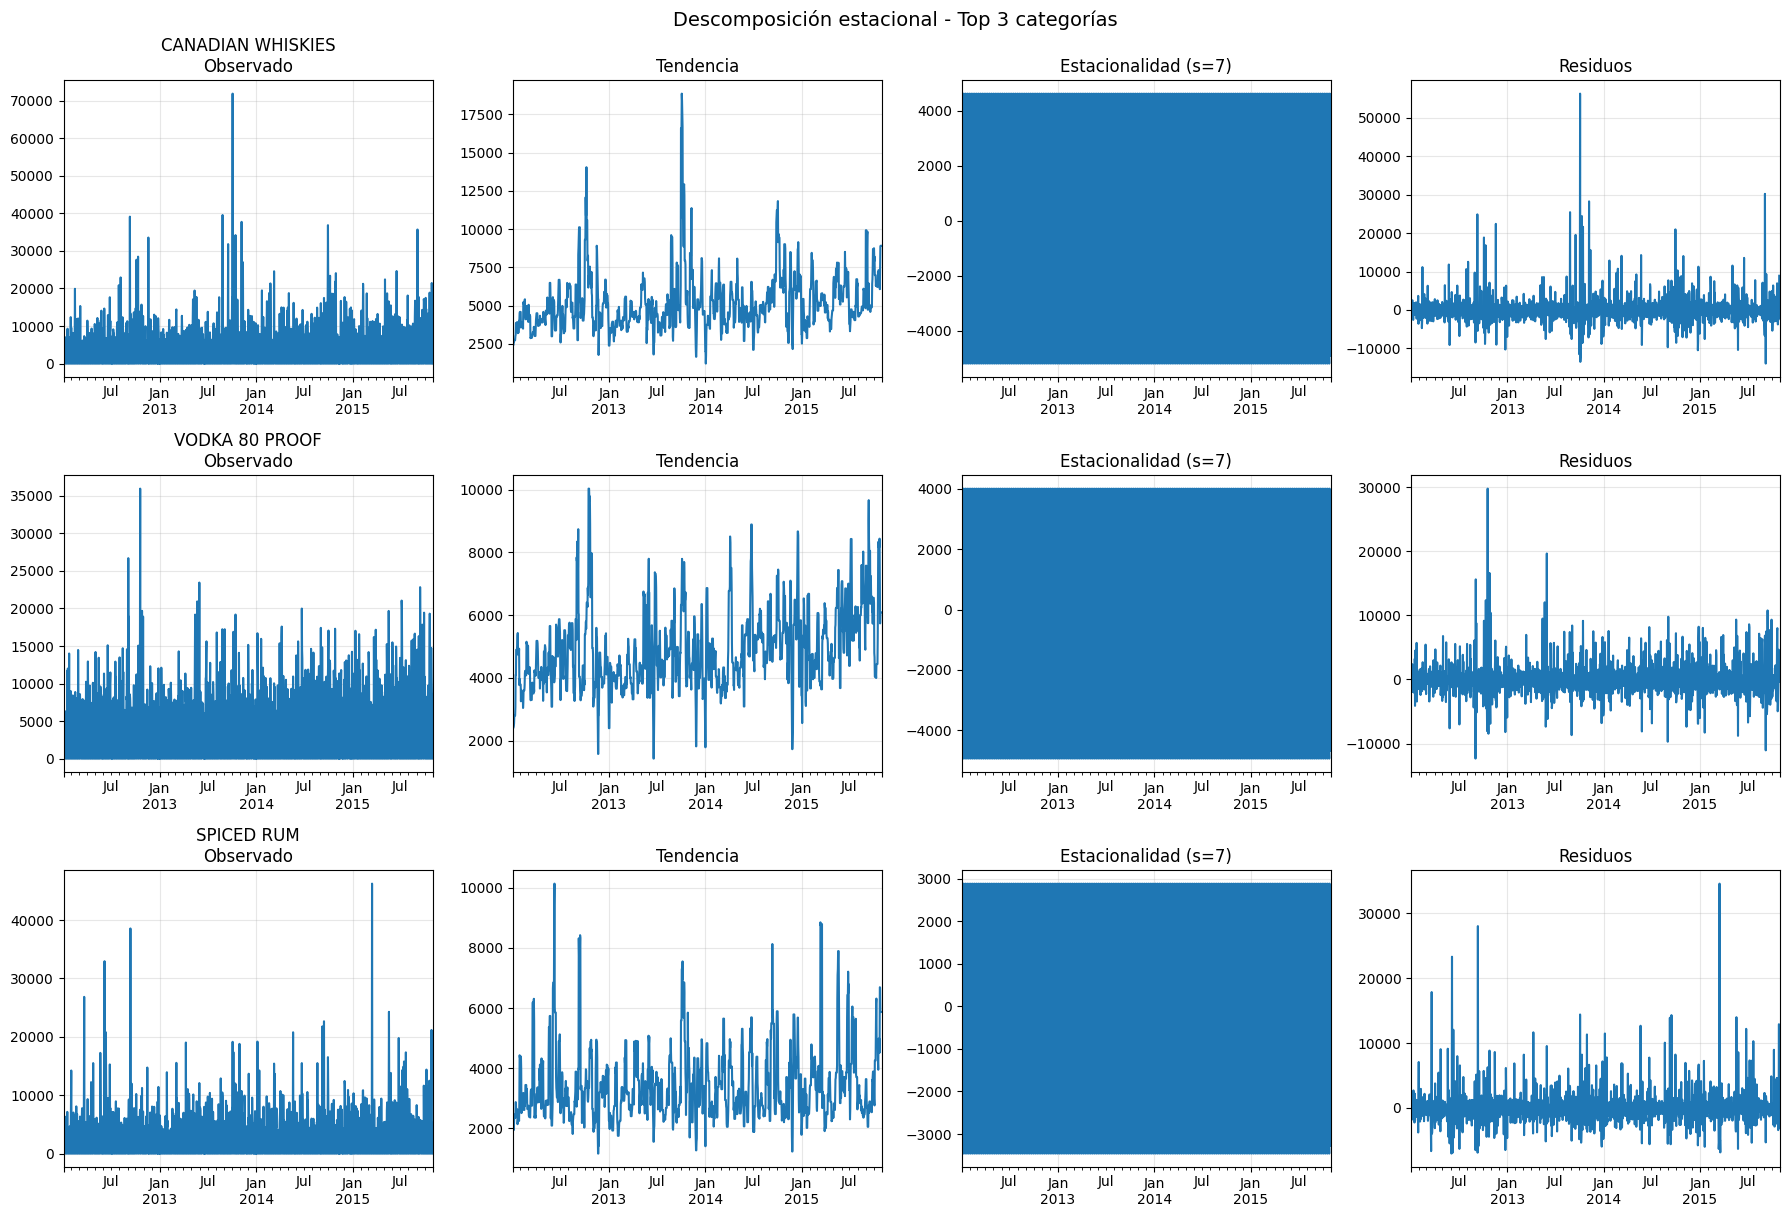

In [21]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Top 3 categorías por volumen total de ventas
top3_cats = (
    ventas_categoria.groupby("categoria")["ventas"].sum()
    .nlargest(3).index.tolist()
)
print(f"Top 3 categorías para diagnóstico: {top3_cats}")

# Preparar series diarias con reindex (fillna(0) es válido a nivel categoría agregada)
series_diag = {}
full_dates = pd.date_range(ventas_categoria["fecha"].min(), cutoff, freq="D")

for cat in top3_cats:
    s = (
        train_cat[train_cat["categoria"] == cat]
        .set_index("fecha")["ventas"]
        .reindex(full_dates)
        .fillna(0)
    )
    s.index.freq = "D"
    series_diag[cat] = s

# --- 1. Descomposición estacional (período=7 para semanal) ---
fig, axes = plt.subplots(len(top3_cats), 4, figsize=(18, 4 * len(top3_cats)))
for i, (cat, s) in enumerate(series_diag.items()):
    result = seasonal_decompose(s, model="additive", period=7)
    result.observed.plot(ax=axes[i, 0], title=f"{cat[:30]}\nObservado")
    result.trend.plot(ax=axes[i, 1], title="Tendencia")
    result.seasonal.plot(ax=axes[i, 2], title="Estacionalidad (s=7)")
    result.resid.plot(ax=axes[i, 3], title="Residuos")
    for ax in axes[i]:
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle("Descomposición estacional - Top 3 categorías", y=1.01, fontsize=14)
plt.show()

In [22]:
# --- 2. Test ADF (Augmented Dickey-Fuller) ---
# H0: la serie tiene raíz unitaria (NO es estacionaria)
# Si p-value < 0.05 → rechazamos H0 → la serie ES estacionaria → d=0
# Si p-value >= 0.05 → no rechazamos → necesita diferenciación → d=1
# si no hay intercept es porque la serie oscila alrededor de cero

#el AIC penaliza complejidad: más parámetros → penalización mayor.
# cuanto menor sea, mejor

print("Test ADF (Augmented Dickey-Fuller)")
print("=" * 60)
adf_results = {}
for cat, s in series_diag.items():
    result = adfuller(s.dropna(), autolag="AIC")
    adf_results[cat] = {
        "adf_stat": result[0],
        "p_value": result[1],
        "lags_used": result[2],
        "estacionaria": result[1] < 0.05,
        "d_sugerido": 0 if result[1] < 0.05 else 1,
    }
    status = "ESTACIONARIA (d=0)" if result[1] < 0.05 else "NO estacionaria (d=1)"
    print(f"\n{cat[:40]}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Lags used: {result[2]}")
    print(f"  → {status}")

Test ADF (Augmented Dickey-Fuller)

CANADIAN WHISKIES:
  ADF Statistic: -5.9258
  p-value: 0.000000
  Lags used: 20
  → ESTACIONARIA (d=0)

VODKA 80 PROOF:
  ADF Statistic: -6.1787
  p-value: 0.000000
  Lags used: 22
  → ESTACIONARIA (d=0)

SPICED RUM:
  ADF Statistic: -7.4940
  p-value: 0.000000
  Lags used: 23
  → ESTACIONARIA (d=0)


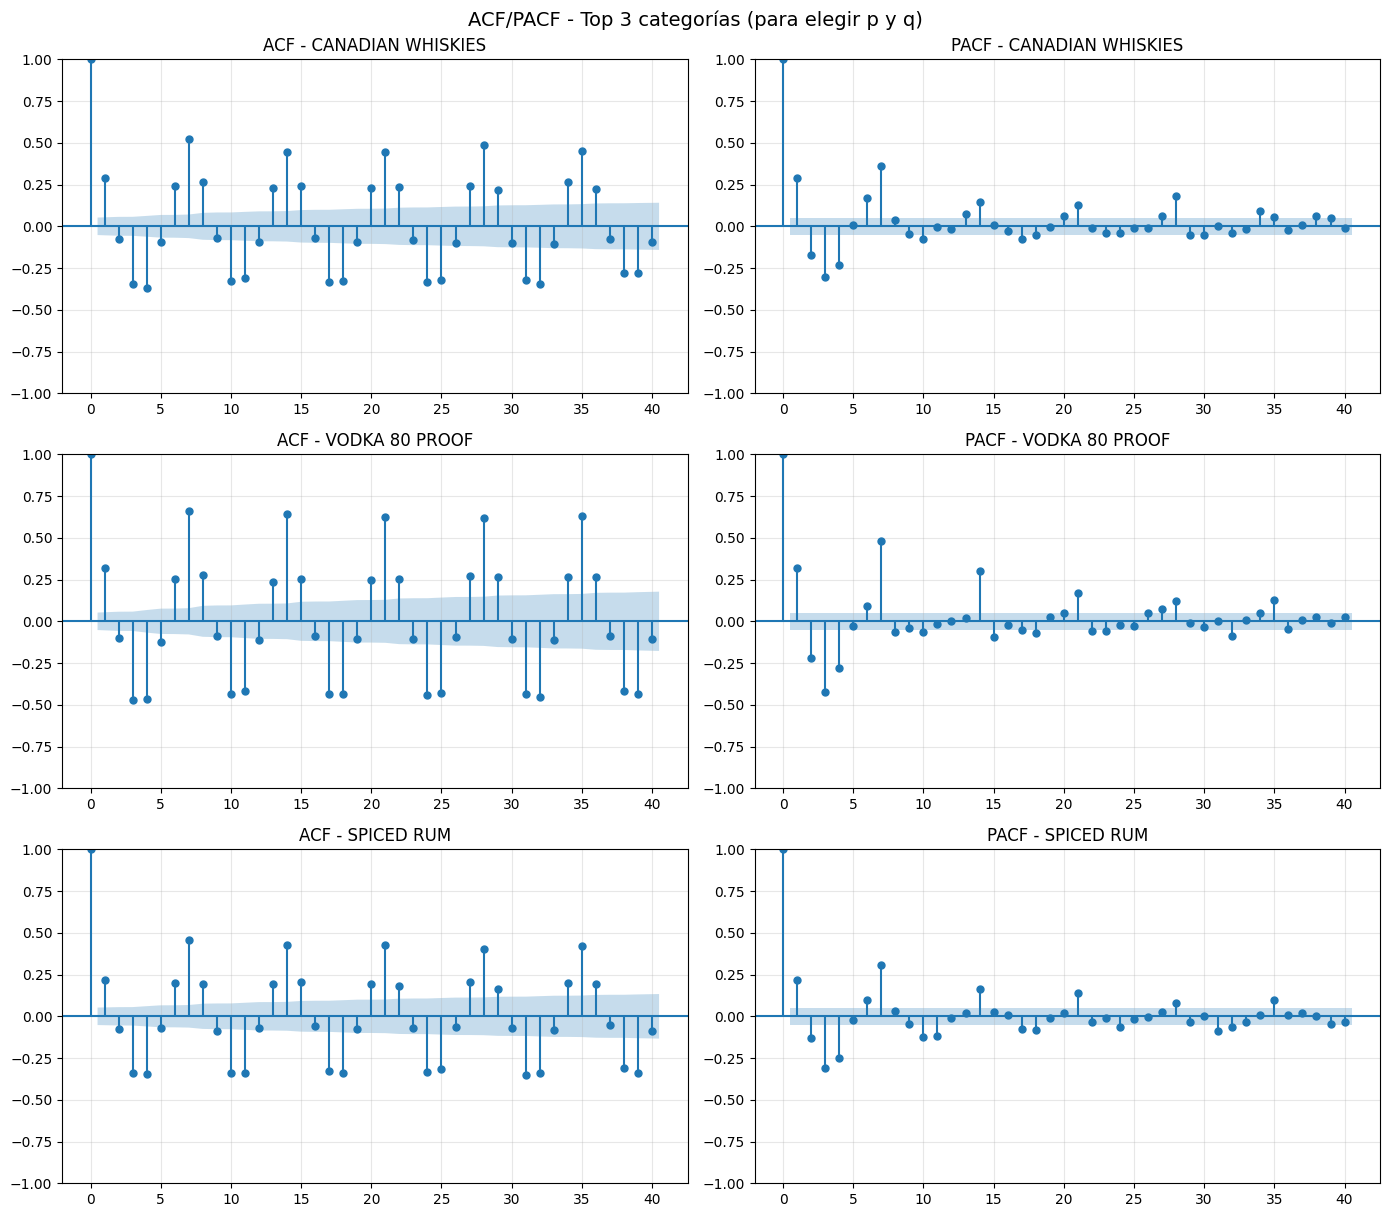


Interpretación:
- ACF con picos significativos en lag 7, 14, 21 → estacionalidad semanal confirmada
- PACF: el lag donde cae abruptamente sugiere el orden p del AR
- Si PACF tiene corte abrupto en lag 1-2 → p=1 o p=2
- Si ACF tiene corte abrupto en lag 1-2 → q=1 o q=2


In [23]:
# --- 3. ACF/PACF para elegir p y q ---
# ACF: autocorrelación → sugiere q (orden MA)
# PACF: autocorrelación parcial → sugiere p (orden AR)
# Buscamos el lag donde la correlación cae dentro de la banda de confianza
# Si las barras tardan varios lags en entrar a la banda suele indicar no estacionariedad (tendencia) --> d=1
# si el decaimiento es rápido Suele indicar estacionariedad → d = 0... esto implica que sus propiedades estadísticas (media, varianza) no cambian con el tiempo.

fig, axes = plt.subplots(len(top3_cats), 2, figsize=(14, 4 * len(top3_cats)))
for i, (cat, s) in enumerate(series_diag.items()):
    plot_acf(s.dropna(), lags=40, ax=axes[i, 0], title=f"ACF - {cat[:30]}")
    plot_pacf(s.dropna(), lags=40, ax=axes[i, 1], title=f"PACF - {cat[:30]}")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle("ACF/PACF - Top 3 categorías (para elegir p y q)", y=1.01, fontsize=14)
plt.show()

print("\nInterpretación:")
print("- ACF con picos significativos en lag 7, 14, 21 → estacionalidad semanal confirmada")
print("- PACF: el lag donde cae abruptamente sugiere el orden p del AR")
print("- Si PACF tiene corte abrupto en lag 1-2 → p=1 o p=2")
print("- Si ACF tiene corte abrupto en lag 1-2 → q=1 o q=2")

---
## Fase 5: SARIMA — Estacionalidad semanal

### Tratamiento contextual de `fillna`

| Nivel | Tratamiento | Razón |
|-------|-------------|-------|
| **Categoría (todo Iowa)** | `fillna(0)` | Sin registro = sin venta real a nivel estatal |
| **Tienda individual** | Detectar días de cierre (0 transacciones en TODAS las categorías) y excluirlos | Tienda cerrada ≠ demanda cero |

### Parámetros SARIMA
Usamos `pmdarima.auto_arima` para encontrar los mejores (p,d,q)(P,D,Q)[7] en las top 3 categorías. Luego aplicamos esos parámetros al resto como punto de partida razonable. 

In [24]:
# auto_arima para encontrar parámetros óptimos en las top 3 categorías
try:
    import pmdarima as pm
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    import pmdarima as pm

print("auto_arima: buscando parámetros óptimos (puede tardar 1-2 min por serie)")
print("=" * 60)
auto_results = {}
for cat in top3_cats:
    s = series_diag[cat]
    print(f"\n{cat}:")
    auto_model = pm.auto_arima(
        s,
        seasonal=True,
        m=7,                  # estacionalidad semanal
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        d=None, D=None,       # auto-detectar diferenciación
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        trace=True,
    )
    order = auto_model.order
    seasonal = auto_model.seasonal_order
    aic = auto_model.aic()
    auto_results[cat] = {
        "order": order,
        "seasonal_order": seasonal,
        "aic": aic,
        "model": auto_model,
    }
    print(f"  → Mejor modelo: SARIMA{order}{seasonal}")
    print(f"  → AIC: {aic:.1f}")

print("\n" + "=" * 60)
print("Resumen de parámetros encontrados por auto_arima:")
for cat, r in auto_results.items():
    print(f"  {cat[:35]:35s} → SARIMA{r['order']}{r['seasonal_order']} (AIC={r['aic']:.0f})")

# Guardar modelos en disco para reutilizarlos sin reajustar
import joblib

MODELS_PATH = OUTPUT_DIR / "sarima_models_top3.joblib"
save_dict = {
    cat: {
        "model": r["model"],
        "order": r["order"],
        "seasonal_order": r["seasonal_order"],
        "aic": r["aic"],
    }
    for cat, r in auto_results.items()
}
joblib.dump(save_dict, MODELS_PATH)
print(f"\nModelos guardados en: {MODELS_PATH}")

auto_arima: buscando parámetros óptimos (puede tardar 1-2 min por serie)

CANADIAN WHISKIES:
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=10.11 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=28789.092, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=28392.071, Time=0.71 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=2.70 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=28787.093, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=28704.392, Time=0.20 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=28332.035, Time=1.65 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=28107.710, Time=10.92 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=28033.140, Time=6.18 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=28499.743, Time=0.60 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=inf, Time=7.34 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=28431.767, Time=1.29 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=11.51 sec
 ARIMA(0,1,0)(

### Cargar modelos guardados (sin re-ejecutar auto_arima)

Si ya ejecutaste auto_arima y guardaste los modelos, ejecuta la celda de abajo para cargarlos. Luego podrás usar `auto_results[cat]["model"].predict(n_periods=30)` para predecir.

In [25]:
# Opcional: cargar modelos guardados sin re-ejecutar auto_arima
# Descomenta y ejecuta solo esta celda si ya tienes modelos guardados

MODELS_PATH = OUTPUT_DIR / "sarima_models_top3.joblib"
if MODELS_PATH.exists():
    import joblib
    saved_models = joblib.load(MODELS_PATH)
    auto_results = {
        cat: {
            "order": d["order"],
            "seasonal_order": d["seasonal_order"],
            "aic": d["aic"],
            "model": d["model"],
        }
        for cat, d in saved_models.items()
    }
    print("Modelos cargados desde:", MODELS_PATH)
    for cat, r in auto_results.items():
        print(f"  {cat[:35]:35s} → SARIMA{r['order']}{r['seasonal_order']} (AIC={r['aic']:.0f})")
else:
    print("No hay modelos guardados. Ejecuta la celda anterior (auto_arima) primero.")

Modelos cargados desde: data\sarima_models_top3.joblib
  CANADIAN WHISKIES                   → SARIMA(1, 1, 0)(1, 0, 1, 7) (AIC=28033)
  VODKA 80 PROOF                      → SARIMA(3, 1, 0)(1, 0, 1, 7) (AIC=26734)
  SPICED RUM                          → SARIMA(0, 0, 2)(2, 0, 1, 7) (AIC=26936)


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, desc=""):
        return iterable

# Parámetros: usar los encontrados por auto_arima del primer top cat, o fallback conservador
# Se elige el más común entre los resultados de auto_arima
if auto_results:
    first_result = list(auto_results.values())[0]
    ORDER = first_result["order"]
    SEASONAL_ORDER = first_result["seasonal_order"]
else:
    ORDER = (1, 0, 1)
    SEASONAL_ORDER = (1, 0, 1, 7)

MIN_DAYS = 90
STEPS_AHEAD = 30

print(f"Parámetros SARIMA elegidos: {ORDER} x {SEASONAL_ORDER}")
print(f"Filtro: mínimo {MIN_DAYS} días de datos por serie")
print(f"Horizonte de predicción: {STEPS_AHEAD} días")


def prepare_series_cat(df, group_key, group_col, date_col="fecha", value_col="ventas", all_dates=None):
    """Reindexa a fechas diarias. fillna(0) para categorías (sin registro = sin venta a nivel estatal)."""
    g = df[df[group_col] == group_key]
    s = g.set_index(date_col)[value_col]
    if all_dates is None:
        all_dates = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(all_dates).fillna(0)
    return s


def prepare_series_store(df, group_key, group_col, closed_days_by_store,
                         date_col="fecha", value_col="ventas", all_dates=None):
    """Reindexa a fechas diarias. Excluye días de cierre para tiendas."""
    g = df[df[group_col] == group_key]
    s = g.set_index(date_col)[value_col]
    if all_dates is None:
        all_dates = pd.date_range(s.index.min(), s.index.max(), freq="D")
    s = s.reindex(all_dates)
    # Marcar días de cierre como NaN en vez de 0
    if group_key in closed_days_by_store:
        closed = closed_days_by_store[group_key]
        s.loc[s.index.isin(closed) & s.isna()] = np.nan
    # Días con dato faltante que NO son cierre → fillna(0) (categoría no vendida pero tienda abierta)
    s = s.fillna(0)
    # Eliminar NaN restantes (días de cierre)
    s = s.dropna()
    return s

Parámetros SARIMA elegidos: (1, 1, 0) x (1, 0, 1, 7)
Filtro: mínimo 90 días de datos por serie
Horizonte de predicción: 30 días


In [27]:
# Detectar días de cierre por tienda: un día donde la tienda no tiene
# NINGUNA transacción en ninguna categoría es probable cierre
# (vs. una categoría sin ventas pero tienda abierta)

store_days = train_store.groupby("store_id")["fecha"].apply(set).to_dict()
all_train_dates = set(pd.date_range(train_store["fecha"].min(), cutoff, freq="D"))

closed_days_by_store = {}
for store_id, open_days in store_days.items():
    closed = all_train_dates - open_days
    if len(closed) > 0:
        closed_days_by_store[store_id] = closed

total_stores = len(store_days)
stores_with_closures = len(closed_days_by_store)
avg_closed = np.mean([len(v) for v in closed_days_by_store.values()]) if closed_days_by_store else 0
print(f"Tiendas con días de cierre detectados: {stores_with_closures}/{total_stores}")
print(f"Promedio de días de cierre por tienda: {avg_closed:.0f}")


def _fit_sarima(key, train_df, test_df, group_col, cutoff, prepare_fn, **prepare_kwargs):
    """Entrena SARIMA para un grupo. Retorna (key, result) o None."""
    g_train = train_df[train_df[group_col] == key]
    if g_train["fecha"].nunique() < MIN_DAYS:
        return None

    min_date = g_train["fecha"].min()
    all_dates = pd.date_range(min_date, cutoff, freq="D")
    train_y = prepare_fn(train_df, key, group_col, all_dates=all_dates, **prepare_kwargs)

    if len(train_y) < MIN_DAYS:
        return None

    test_subset = test_df[test_df[group_col] == key]
    if len(test_subset) == 0:
        return None

    try:
        model = SARIMAX(
            train_y, order=ORDER, seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False, enforce_invertibility=False,
        )
        fit = model.fit(disp=False)
        pred = fit.forecast(steps=STEPS_AHEAD)
        actual_series = test_subset.groupby("fecha")["ventas"].sum()
        actual_aligned = actual_series.reindex(pred.index).fillna(0)
        return (key, {"pred": pred, "actual": actual_aligned})
    except Exception:
        return None


# --- SARIMA por categoría ---
cat_groups = train_cat.groupby("categoria")["fecha"].nunique()
valid_cats = cat_groups[cat_groups >= MIN_DAYS].index.tolist()

results_cat = Parallel(n_jobs=4)(
    delayed(_fit_sarima)(
        cat, train_cat, test_cat, "categoria", cutoff,
        prepare_series_cat
    )
    for cat in tqdm(valid_cats, desc="SARIMA categoría")
)
results_categoria = dict(x for x in results_cat if x is not None)
print(f"\nModelos SARIMA entrenados - Categorías: {len(results_categoria)}")

Tiendas con días de cierre detectados: 1561/1561
Promedio de días de cierre por tienda: 1306


SARIMA categoría: 100%|██████████| 65/65 [00:58<00:00,  1.10it/s]



Modelos SARIMA entrenados - Categorías: 63


In [28]:
# --- SARIMA por tienda (con exclusión de días de cierre) ---
store_groups = train_store.groupby("store_id")["fecha"].nunique()
valid_stores = store_groups[store_groups >= MIN_DAYS].index.tolist()
# Muestra de 400 tiendas para reducir tiempo
if len(valid_stores) > 400:
    valid_stores = np.random.choice(valid_stores, 400, replace=False).tolist()

results_store = Parallel(n_jobs=4)(
    delayed(_fit_sarima)(
        sid, train_store, test_store, "store_id", cutoff,
        prepare_series_store, closed_days_by_store=closed_days_by_store
    )
    for sid in tqdm(valid_stores, desc="SARIMA tienda")
)
results_tienda = dict(x for x in results_store if x is not None)
print(f"Modelos SARIMA entrenados - Tiendas: {len(results_tienda)}")

SARIMA tienda: 100%|██████████| 400/400 [10:35<00:00,  1.59s/it]


Modelos SARIMA entrenados - Tiendas: 358


WMAPE: Es un MAPE ponderado por las magnitudes reales, es mas estable cuando hay valores muy pequeños

MAE: Error absoluto promedio. Misma unidad que la serie. No penaliza mucho los errores grandes.

RMSE: Penaliza más los errores grandes. Misma unidad que la serie.

MAPE: Error en porcentaje.

SARIMA Categorías: WMAPE=62.2% | MAPE=130.2% | MAE=$477 | RMSE=$1,695 | series=63
SARIMA Tiendas: WMAPE=99.1% | MAPE=97.1% | MAE=$58 | RMSE=$282 | series=358


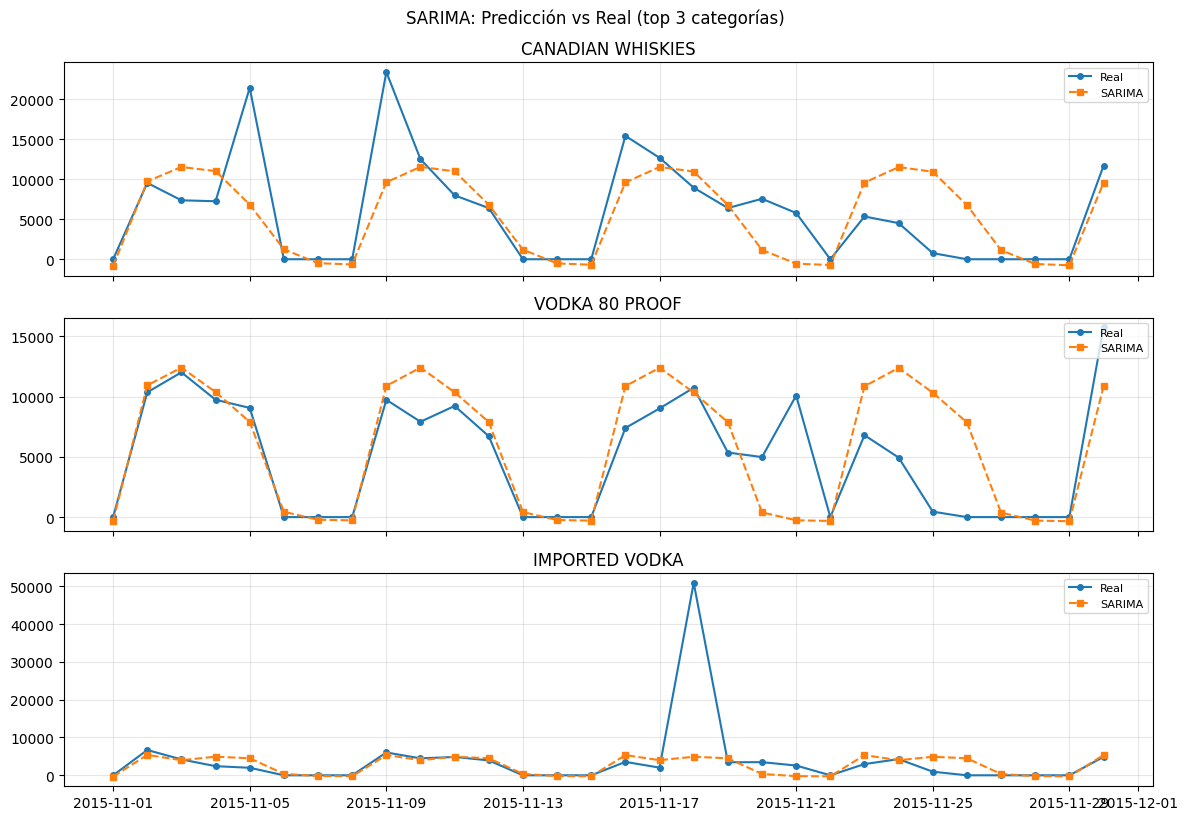

In [29]:
# Evaluación SARIMA con WMAPE (métrica principal) + MAPE + MAE
def evaluate_sarima(results, label=""):
    """Evalúa SARIMA con WMAPE, MAPE y MAE."""
    all_actual = np.concatenate([r["actual"].values for r in results.values()])
    all_pred = np.concatenate([r["pred"].values for r in results.values()])
    w = wmape(all_actual, all_pred)
    m = mape(all_actual, all_pred)
    ma = mae(all_actual, all_pred)
    rm = rmse(all_actual, all_pred)
    print(f"SARIMA {label}: WMAPE={w:.1%} | MAPE={m:.1f}% | MAE=${ma:,.0f} | RMSE=${rm:,.0f} | series={len(results)}")
    return {"wmape": w, "mape": m, "mae": ma, "rmse": rm, "n_series": len(results)}

eval_sarima_cat = evaluate_sarima(results_categoria, "Categorías")
eval_sarima_store = evaluate_sarima(results_tienda, "Tiendas")

# Visualización: predicción vs real para top 3 categorías
df_actuals = pd.DataFrame({k: r["actual"] for k, r in results_categoria.items()})
top_vis = df_actuals.sum().nlargest(3).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, cat in zip(axes, top_vis):
    if cat in results_categoria:
        r = results_categoria[cat]
        ax.plot(r["actual"].index, r["actual"].values, "o-", label="Real", markersize=4)
        ax.plot(r["pred"].index, r["pred"].values, "s--", label="SARIMA", markersize=4)
        ax.set_title(str(cat)[:50])
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle("SARIMA: Predicción vs Real (top 3 categorías)", y=1.02)
plt.show()

---
## Fase 6: XGBoost y LightGBM

Modelo **global** (una sola instancia para todas las categorías, usando `categoria_enc` como feature). Ventajas:
- Categorías con pocos datos se benefician del conocimiento compartido
- Un solo modelo para mantener

### Features por categoría (PARTITION BY)

| Feature | Propósito |
|---------|-----------|
| `lag_1`, `lag_7`, `lag_14`, `lag_28` | Autocorrelación y estacionalidad |
| `roll_mean_7`, `roll_mean_28` | Nivel base reciente (excluyen día actual) |
| `dia_semana`, `mes`, `dia_mes` | Estacionalidad calendario |
| `es_finde` | Indicador binario fin de semana |
| `ratio_lag7_roll28` | Cambio relativo vs promedio |
| `trend_7` | Tendencia corto vs largo plazo |

In [30]:
# Feature engineering por categoría con PARTITION BY
path_cat = (OUTPUT_DIR / "ventas_por_categoria.parquet").as_posix()
df_cat_raw = duckdb.query(f"SELECT * FROM '{path_cat}'").to_df()
if not pd.api.types.is_datetime64_any_dtype(df_cat_raw["fecha"]):
    df_cat_raw["fecha"] = pd.to_datetime(df_cat_raw["fecha"])

con_xgb = duckdb.connect(":memory:")
con_xgb.register("ventas_cat", df_cat_raw)

df_xgb = con_xgb.execute("""
    SELECT
        fecha, categoria, ventas,
        LAG(ventas, 1)  OVER w AS lag_1,
        LAG(ventas, 7)  OVER w AS lag_7,
        LAG(ventas, 14) OVER w AS lag_14,
        LAG(ventas, 28) OVER w AS lag_28,
        AVG(ventas) OVER (w ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING) AS roll_mean_7,
        AVG(ventas) OVER (w ROWS BETWEEN 28 PRECEDING AND 1 PRECEDING) AS roll_mean_28,
        EXTRACT('dayofweek' FROM fecha)::INTEGER AS dia_semana,
        EXTRACT('month' FROM fecha)::INTEGER AS mes,
        EXTRACT('day' FROM fecha)::INTEGER AS dia_mes,
        CASE WHEN EXTRACT('dayofweek' FROM fecha) IN (0, 6) THEN 1 ELSE 0 END AS es_finde
    FROM ventas_cat
    WINDOW w AS (PARTITION BY categoria ORDER BY fecha)
    ORDER BY categoria, fecha
""").fetchdf()
con_xgb.close()

# Eliminar warm-up (filas sin lag_28)
df_xgb = df_xgb[df_xgb["lag_28"].notna()].copy()

# Features derivadas
df_xgb["ratio_lag7_roll28"] = df_xgb["lag_7"] / df_xgb["roll_mean_28"].replace(0, np.nan)
df_xgb["trend_7"] = (df_xgb["roll_mean_7"] - df_xgb["roll_mean_28"]) / df_xgb["roll_mean_28"].replace(0, np.nan)
df_xgb["ratio_lag7_roll28"] = df_xgb["ratio_lag7_roll28"].fillna(1.0)
df_xgb["trend_7"] = df_xgb["trend_7"].fillna(0.0)

# Label encoding de categoría
from sklearn.preprocessing import LabelEncoder
le_categoria = LabelEncoder()
df_xgb["categoria_enc"] = le_categoria.fit_transform(df_xgb["categoria"].astype(str))

FEATURES = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_mean_28",
    "dia_semana", "mes", "dia_mes", "es_finde",
    "ratio_lag7_roll28", "trend_7",
    "categoria_enc",
]
TARGET = "ventas"

print(f"Filas tras warm-up: {len(df_xgb):,} | Categorías: {len(le_categoria.classes_)}")
print(f"Features: {len(FEATURES)}")

Filas tras warm-up: 38,998 | Categorías: 68
Features: 13


In [31]:
# Split temporal (consistente con SARIMA)
fecha_max_xgb = df_xgb["fecha"].max()
cutoff_xgb = fecha_max_xgb - pd.Timedelta(days=30)

train_xgb = df_xgb[df_xgb["fecha"] <= cutoff_xgb].dropna(subset=FEATURES)
test_xgb = df_xgb[df_xgb["fecha"] > cutoff_xgb].dropna(subset=FEATURES)

X_train = train_xgb[FEATURES]
y_train = train_xgb[TARGET]
X_test = test_xgb[FEATURES]
y_test = test_xgb[TARGET]

print(f"Cutoff: {cutoff_xgb.date()}")
print(f"Train: {len(X_train):,} filas | Test: {len(X_test):,} filas")

Cutoff: 2015-10-31
Train: 38,115 filas | Test: 883 filas


In [32]:
# --- XGBoost ---
try:
    import xgboost as xgb
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1,
)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# --- LightGBM ---
try:
    import lightgbm as lgb
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm"])
    import lightgbm as lgb

model_lgb = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="regression",
    n_jobs=-1,
    verbose=-1,
)
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)],
)

print("\nModelos entrenados: XGBoost + LightGBM")

[0]	validation_0-rmse:3050.71494
[50]	validation_0-rmse:2278.35136
[100]	validation_0-rmse:2275.53253
[150]	validation_0-rmse:2282.62039
[199]	validation_0-rmse:2297.22142
[50]	valid_0's l2: 5.17944e+06
[100]	valid_0's l2: 5.12707e+06

Modelos entrenados: XGBoost + LightGBM


Evaluación XGBoost/LightGBM
XGBoost:  WMAPE=49.7% | MAPE=181.7% | MAE=$831 | RMSE=$2,297
LightGBM: WMAPE=48.5% | MAPE=213.4% | MAE=$812 | RMSE=$2,261


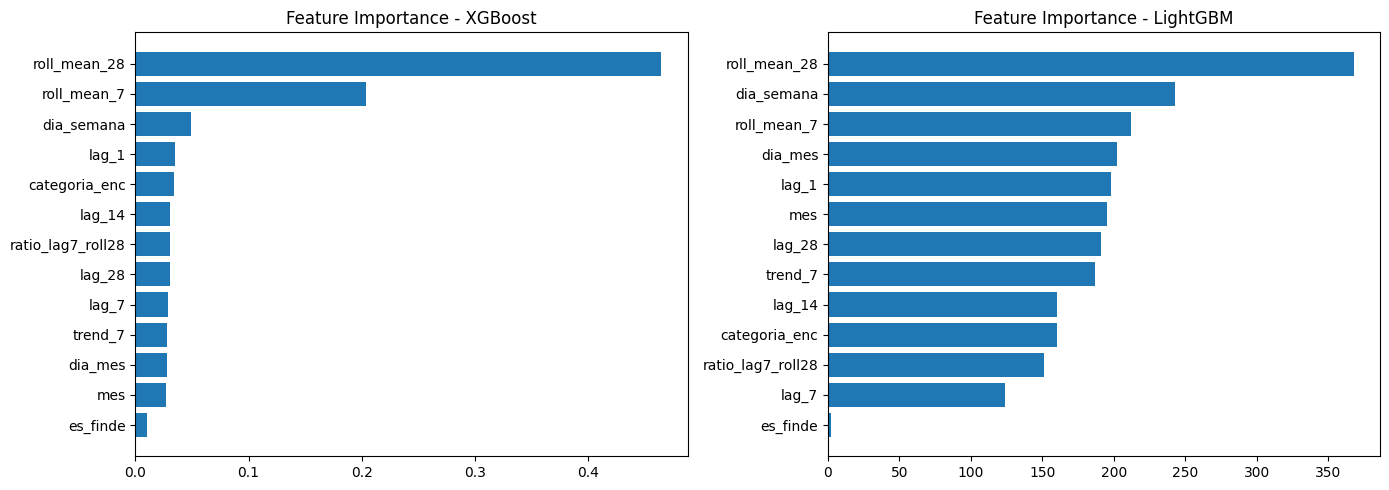

In [33]:
# Predicciones
pred_xgb = model_xgb.predict(X_test)
pred_lgb = model_lgb.predict(X_test)

# Evaluación con WMAPE (métrica principal) + complementarias
print("Evaluación XGBoost/LightGBM")
print("=" * 60)
y_true = y_test.values

eval_xgb = {
    "wmape": wmape(y_true, pred_xgb),
    "mape": mape(y_true, pred_xgb),
    "mae": mae(y_true, pred_xgb),
    "rmse": rmse(y_true, pred_xgb),
}
eval_lgb = {
    "wmape": wmape(y_true, pred_lgb),
    "mape": mape(y_true, pred_lgb),
    "mae": mae(y_true, pred_lgb),
    "rmse": rmse(y_true, pred_lgb),
}

print(f"XGBoost:  WMAPE={eval_xgb['wmape']:.1%} | MAPE={eval_xgb['mape']:.1f}% | MAE=${eval_xgb['mae']:,.0f} | RMSE=${eval_xgb['rmse']:,.0f}")
print(f"LightGBM: WMAPE={eval_lgb['wmape']:.1%} | MAPE={eval_lgb['mape']:.1f}% | MAE=${eval_lgb['mae']:,.0f} | RMSE=${eval_lgb['rmse']:,.0f}")

# Feature importance
imp_xgb = pd.DataFrame({"feature": FEATURES, "importance": model_xgb.feature_importances_}).sort_values("importance", ascending=False)
imp_lgb = pd.DataFrame({"feature": FEATURES, "importance": model_lgb.feature_importances_}).sort_values("importance", ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.barh(imp_xgb["feature"], imp_xgb["importance"])
ax1.set_title("Feature Importance - XGBoost")
ax1.invert_yaxis()
ax2.barh(imp_lgb["feature"], imp_lgb["importance"])
ax2.set_title("Feature Importance - LightGBM")
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Fase 7: Ensemble y Tabla Comparativa

### Ensemble
Promedio ponderado de XGBoost y LightGBM (mismos datos de test). Los pesos se optimizan por WMAPE.

### Walk-forward validation
Validamos la robustez del mejor modelo con 3 folds temporales.

In [34]:
# --- Ensemble: buscar peso óptimo entre XGBoost y LightGBM ---
best_w, best_wmape_ens = 0.5, 1.0
for w in np.arange(0.0, 1.05, 0.05):
    pred_ens = w * pred_xgb + (1 - w) * pred_lgb
    w_score = wmape(y_true, pred_ens)
    if w_score < best_wmape_ens:
        best_w, best_wmape_ens = w, w_score

pred_ensemble = best_w * pred_xgb + (1 - best_w) * pred_lgb
eval_ensemble = {
    "wmape": wmape(y_true, pred_ensemble),
    "mape": mape(y_true, pred_ensemble),
    "mae": mae(y_true, pred_ensemble),
    "rmse": rmse(y_true, pred_ensemble),
}
print(f"Ensemble óptimo: {best_w:.0%} XGBoost + {1-best_w:.0%} LightGBM")
print(f"Ensemble: WMAPE={eval_ensemble['wmape']:.1%} | MAPE={eval_ensemble['mape']:.1f}% | MAE=${eval_ensemble['mae']:,.0f} | RMSE=${eval_ensemble['rmse']:,.0f}")

# --- Tabla comparativa final ---
print("\n" + "=" * 80)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 80)

comparacion = pd.DataFrame([
    {"Modelo": "SARIMA (por categoría)", "WMAPE": f"{eval_sarima_cat['wmape']:.1%}",
     "MAPE (%)": f"{eval_sarima_cat['mape']:.1f}", "MAE ($)": f"{eval_sarima_cat['mae']:,.0f}",
     "RMSE ($)": f"{eval_sarima_cat['rmse']:,.0f}", "Notas": f"auto_arima {ORDER}x{SEASONAL_ORDER}"},
    {"Modelo": "XGBoost (global)", "WMAPE": f"{eval_xgb['wmape']:.1%}",
     "MAPE (%)": f"{eval_xgb['mape']:.1f}", "MAE ($)": f"{eval_xgb['mae']:,.0f}",
     "RMSE ($)": f"{eval_xgb['rmse']:,.0f}", "Notas": "13 features, 200 trees"},
    {"Modelo": "LightGBM (global)", "WMAPE": f"{eval_lgb['wmape']:.1%}",
     "MAPE (%)": f"{eval_lgb['mape']:.1f}", "MAE ($)": f"{eval_lgb['mae']:,.0f}",
     "RMSE ($)": f"{eval_lgb['rmse']:,.0f}", "Notas": "13 features, leaf-wise"},
    {"Modelo": f"Ensemble ({best_w:.0%}XGB+{1-best_w:.0%}LGB)", "WMAPE": f"{eval_ensemble['wmape']:.1%}",
     "MAPE (%)": f"{eval_ensemble['mape']:.1f}", "MAE ($)": f"{eval_ensemble['mae']:,.0f}",
     "RMSE ($)": f"{eval_ensemble['rmse']:,.0f}", "Notas": "Promedio ponderado"},
])
display(comparacion)

Ensemble óptimo: 0% XGBoost + 100% LightGBM
Ensemble: WMAPE=48.5% | MAPE=213.4% | MAE=$812 | RMSE=$2,261

TABLA COMPARATIVA DE MODELOS


,Modelo,WMAPE,MAPE (%),MAE ($),RMSE ($),Notas
0,SARIMA (por categoría),62.2%,130.2,477,"1,695","auto_arima (1, 1, 0)x(1, 0, 1, 7)"
1,XGBoost (global),49.7%,181.7,831,"2,297","13 features, 200 trees"
2,LightGBM (global),48.5%,213.4,812,"2,261","13 features, leaf-wise"
3,Ensemble (0%XGB+100%LGB),48.5%,213.4,812,"2,261",Promedio ponderado


In [35]:
#  Walk-forward validation ( ntrenar hasta una fecha, predecir el futuro, avanzar en el tiempo y repetir.) 
# Cada uno de los 3 folds se entrena solo con pasado y evalúa en futuro respecto a ese train

# no se usa el K-folds clasico porque se estarian mezclando fechas, lo que causaria Data leakage y romperia la validez del modelo

print("Walk-forward validation (3 folds)")
print("=" * 60)

fecha_min_xgb = df_xgb["fecha"].min()
fecha_max_xgb = df_xgb["fecha"].max()
total_days = (fecha_max_xgb - fecha_min_xgb).days

fold_results = []
for fold_i in range(3):
    # Cutoff retrocede 30 días por cada fold
    fold_cutoff = fecha_max_xgb - pd.Timedelta(days=30 * (fold_i + 1))
    fold_test_end = fold_cutoff + pd.Timedelta(days=30)

    fold_train = df_xgb[df_xgb["fecha"] <= fold_cutoff].dropna(subset=FEATURES)
    fold_test = df_xgb[(df_xgb["fecha"] > fold_cutoff) & (df_xgb["fecha"] <= fold_test_end)].dropna(subset=FEATURES)

    if len(fold_test) == 0:
        continue

    # Re-entrenar XGBoost en este fold
    model_fold = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
        random_state=42, objective="reg:squarederror", n_jobs=-1,
    )
    model_fold.fit(fold_train[FEATURES], fold_train[TARGET], verbose=0)
    fold_pred = model_fold.predict(fold_test[FEATURES])
    fold_actual = fold_test[TARGET].values

    fold_wmape = wmape(fold_actual, fold_pred)
    fold_mae = mae(fold_actual, fold_pred)
    fold_results.append({"fold": fold_i + 1, "cutoff": fold_cutoff.date(), "wmape": fold_wmape, "mae": fold_mae, "n_test": len(fold_test)})
    print(f"  Fold {fold_i+1}: cutoff={fold_cutoff.date()} | WMAPE={fold_wmape:.1%} | MAE=${fold_mae:,.0f} | test={len(fold_test)} filas")

if fold_results:
    avg_wmape = np.mean([f["wmape"] for f in fold_results])
    std_wmape = np.std([f["wmape"] for f in fold_results])
    print(f"\nPromedio WMAPE: {avg_wmape:.1%} (±{std_wmape:.1%})")
    print(f"Varianza baja = modelo robusto; varianza alta = modelo inestable")

Walk-forward validation (3 folds)
  Fold 1: cutoff=2015-10-31 | WMAPE=49.7% | MAE=$831 | test=883 filas
  Fold 2: cutoff=2015-10-01 | WMAPE=47.8% | MAE=$900 | test=801 filas
  Fold 3: cutoff=2015-09-01 | WMAPE=45.1% | MAE=$759 | test=894 filas

Promedio WMAPE: 47.5% (±1.9%)
Varianza baja = modelo robusto; varianza alta = modelo inestable


---
## Fase 8: Ejercicios SQL avanzados (E2.x)

Técnicas SQL adicionales para profundizar habilidades.

### E2.1: QUALIFY + NTILE() — Segmentar tiendas en cuartiles de ventas

**QUALIFY** es un filtro post-window function (exclusivo de DuckDB/Snowflake). Permite filtrar directamente sobre el resultado de una función de ventana sin necesidad de subconsulta.

**NTILE(4)** divide las filas en 4 grupos de tamaño similar (cuartiles).

In [36]:
# E2.1: QUALIFY + NTILE — top quartile de tiendas por ventas totales
# QUALIFY filtra después de calcular la window function (sin subconsulta)
cuartiles = con.execute("""
    SELECT 
        "Store Number" AS store_id,
        SUM(ventas) AS ventas_totales,
        NTILE(4) OVER (ORDER BY SUM(ventas) DESC) AS cuartil
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
    GROUP BY "Store Number"
    QUALIFY NTILE(4) OVER (ORDER BY SUM(ventas) DESC) = 1
    ORDER BY ventas_totales DESC
""").fetchdf()

print(f"Tiendas en el cuartil superior (Q1): {len(cuartiles)}")
print(f"Rango de ventas: ${cuartiles['ventas_totales'].min():,.0f} - ${cuartiles['ventas_totales'].max():,.0f}")
cuartiles.head(10)

Tiendas en el cuartil superior (Q1): 393
Rango de ventas: $34,703 - $2,036,338


,store_id,ventas_totales,cuartil
0,2633,2036338.16,1
1,4829,1376484.01,1
2,3420,977496.30,1
3,3385,958555.77,1
4,2512,897190.85,1
5,3814,791717.99,1
6,3952,691838.43,1
7,2190,649027.91,1
8,3354,597182.10,1
9,3773,513907.30,1


### E2.2: GROUPING SETS / ROLLUP — Totales jerárquicos

**GROUPING SETS** permite calcular múltiples niveles de agregación en una sola query. **ROLLUP** es un atajo para crear subtotales jerárquicos (ej. categoría → total general).

In [37]:
# E2.2: ROLLUP — ventas por categoría con subtotal mensual y total general
# ROLLUP(a, b) genera: (a, b), (a, NULL), (NULL, NULL) = detalle, subtotal, gran total
rollup = con.execute("""
    SELECT 
        date_trunc('month', "Date"::DATE)::DATE AS mes,
        "Category Name" AS categoria,
        SUM(ventas) AS ventas,
        GROUPING(mes) AS is_total_mes,
        GROUPING(categoria) AS is_total_cat
    FROM raw_ventas
    WHERE ventas IS NOT NULL AND ventas >= 0
      AND "Category Name" IN ('CANADIAN WHISKIES', 'VODKA 80 PROOF', 'SPICED RUM')
    GROUP BY ROLLUP(mes, categoria)
    ORDER BY GROUPING(mes), GROUPING(categoria), mes, categoria
""").fetchdf()

# Mostrar totales generales y subtotales mensuales
print("Gran total (ROLLUP):")
display(rollup[rollup["is_total_mes"] == 1])
print("\nSubtotales por mes (sin categoría):")
display(rollup[(rollup["is_total_cat"] == 1) & (rollup["is_total_mes"] == 0)].head(10))

Gran total (ROLLUP):


,mes,categoria,ventas,is_total_mes,is_total_cat
188,NaT,None,19388772.83,1,1



Subtotales por mes (sin categoría):


,mes,categoria,ventas,is_total_mes,is_total_cat
141,2012-01-01,None,286750.78,0,1
142,2012-02-01,None,347954.45,0,1
143,2012-03-01,None,317214.79,0,1
144,2012-04-01,None,353355.00,0,1
145,2012-05-01,None,403441.65,0,1
146,2012-06-01,None,425582.85,0,1
147,2012-07-01,None,372678.99,0,1
148,2012-08-01,None,409073.50,0,1
149,2012-09-01,None,405851.20,0,1
150,2012-10-01,None,607478.96,0,1


### E2.3: Recursive CTE — Generar calendario completo de fechas

**Recursive CTE** genera filas iterativamente. Aquí creamos un calendario de todas las fechas del rango y hacemos LEFT JOIN para detectar gaps en los datos.

In [38]:
# E2.3: Recursive CTE — calendario completo + detección de gaps
gaps = con.execute("""
    WITH RECURSIVE 
    rango AS (
        SELECT MIN("Date"::DATE) AS fecha FROM raw_ventas
        UNION ALL
        SELECT fecha + INTERVAL '1 day' FROM rango
        WHERE fecha < (SELECT MAX("Date"::DATE) FROM raw_ventas)
    ),
    ventas_dia AS (
        SELECT "Date"::DATE AS fecha, COUNT(*) AS n_transacciones
        FROM raw_ventas
        GROUP BY 1
    )
    SELECT 
        r.fecha,
        COALESCE(v.n_transacciones, 0) AS n_transacciones,
        CASE WHEN v.n_transacciones IS NULL THEN 'SIN DATOS' ELSE 'OK' END AS status
    FROM rango r
    LEFT JOIN ventas_dia v ON r.fecha = v.fecha
    WHERE v.n_transacciones IS NULL
    ORDER BY r.fecha
""").fetchdf()

print(f"Días sin ninguna transacción en el dataset: {len(gaps)}")
if len(gaps) > 0:
    print(f"Primeros gaps:")
    display(gaps.head(15))
    # Analizar si son domingos u otros patrones
    gaps["fecha"] = pd.to_datetime(gaps["fecha"])
    gaps["dia_semana"] = gaps["fecha"].dt.day_name()
    print(f"\nDistribución por día de la semana:")
    print(gaps["dia_semana"].value_counts())
else:
    print("No hay gaps — el dataset cubre todos los días del rango.")

Días sin ninguna transacción en el dataset: 560
Primeros gaps:


,fecha,n_transacciones,status
0,2012-01-06,0,SIN DATOS
1,2012-01-07,0,SIN DATOS
2,2012-01-08,0,SIN DATOS
3,2012-01-13,0,SIN DATOS
4,2012-01-14,0,SIN DATOS
5,2012-01-15,0,SIN DATOS
6,2012-01-20,0,SIN DATOS
7,2012-01-21,0,SIN DATOS
8,2012-01-22,0,SIN DATOS
9,2012-01-28,0,SIN DATOS



Distribución por día de la semana:
dia_semana
Sunday       204
Saturday     194
Friday       139
Monday         9
Thursday       7
Wednesday      4
Tuesday        3
Name: count, dtype: int64
